In [1]:
import os
import pypsa
import pandas as pd
pd.options.mode.string_storage = "python"
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np


E0000 00:00:1777472500.587231 14209952 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1777472500.587315 14209952 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1777472500.587321 14209952 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1777472500.587323 14209952 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1777472500.587325 14209952 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


### Data refining

In [ ]:
    PSR_MAP = {
        "wind_on":      ["B19"],
        "wind_off":     ["B18"],
        "solar":        ["B16"],
        "hydro_ror":    ["B11"],
        "hydro_res":    ["B12"],
        "coal":         ["B02", "B03", "B05"],
        "gas":          ["B04"],
    }

    def pivot_generation(zone):
        # Read raw ENTSO-E generation data
        df = pd.read_csv(
            f"data/raw/generation/gen_{zone}_2025.csv",
            parse_dates=["time_utc"]
        )

        tech_series = []

        for tech, psr_list in PSR_MAP.items():
            s = (
                df[df["psr_type"].isin(psr_list)]
                .groupby("time_utc")["generation_MW"]
                .sum()
                .rename(tech)
            )
            tech_series.append(s)

        # Combine into one DataFrame
        gen_pivot = pd.concat(tech_series, axis=1, sort=False).fillna(0.0)

        return gen_pivot


    def pivot_load(zone):
        df = pd.read_csv(
            f"data/raw/load/load_{zone}_2025.csv",
            parse_dates=["time_utc"]
        )

        load = (
            df.set_index("time_utc")["load_MW"]
            .rename("load")
        )

        return load

    ### Calculating the p_max_pu for renewables

    CF_TARGET = {
        "solar": 0.11,
        "wind_on": 0.25,
        "wind_off": 0.52,
        # optional
        "hydro_ror": 0.45,  # reasonable average, document if used
    }

    def compute_p_max_pu(gen, tech):
        """
        Parameters
        ----------
        gen : pd.DataFrame
            Pivoted generation data [MW]
        tech : str
            Column name (e.g. 'wind_on', 'wind_off', 'solar')
        Returns
        -------
        pd.Series
            Hourly p_max_pu profile
        """

        generation = gen[tech]

        # Step 1: normalise by annual maximum
        p_raw = generation / generation.max()

        # Step 2: scale to target capacity factor
        p_max_pu = p_raw / p_raw.mean() * CF_TARGET[tech]

        # Safety: enforce bounds
        p_max_pu = p_max_pu.clip(lower=0.0)

        return p_max_pu


    # helper function to ensure proper formating

    def align_to_snapshots(series, network):
        s = series.copy()

        # Remove timezone if present
        if s.index.tz is not None:
            s.index = s.index.tz_localize(None)

        # 🔧 CRITICAL FIX: remove duplicate timestamps
        if not s.index.is_unique:
            s = s.groupby(s.index).sum()

        # Align to network snapshots
        s = s.reindex(network.snapshots)

        # Fill missing values
        s = s.fillna(0.0)

        return s


    ### Calculating Hydro availability

    gen_NO2 = pivot_generation("NO2")

    # remove timezone if needed
    gen_NO2.index = gen_NO2.index.tz_localize(None)

    # Annual hydro reservoir energy [MWh]
    E_hydro_NO2 = gen_NO2["hydro_res"].sum()

    def hydro_energy_constraint_NO2(n, snapshots):
        model = n.model

        # Dispatch variable for NO2 hydro
        p = model.variables["Generator-p"].loc[
            dict(name="hydro_res_NO2")
        ]   

        # Snapshot weights (1 h each in your case)
        weights = n.snapshot_weightings.generators

        # Annual energy constraint
        model.add_constraints(
            (p * weights).sum(dim="snapshot") <= E_hydro_NO2,
            name="hydro_energy_limit_NO2",
        )

    ## Cost calculations

    costs = pd.read_csv("Data/costs_PyPSA.csv")

    # Keep only 2030
    costs = costs[costs["year"] == 2030].copy()
    costs["value"] = pd.to_numeric(costs["value"], errors="coerce")
    costs = costs.set_index(["technology", "parameter"])


    # Shared costs for all tasks
    def get_cost(tech, param):
        return float(costs.loc[(tech, param), "value"])

    # Solar
    solar_capex = get_cost("solar", "investment") * 1000  # €/MW
    solar_lifetime = get_cost("solar", "lifetime")
    solar_fom_percent = get_cost("solar", "FOM")

    solar_fom = solar_fom_percent / 100 * solar_capex
    solar_marginal_cost = 0

    # Onshore wind
    onshore_capex = get_cost("onwind", "investment") * 1000
    onshore_lifetime = get_cost("onwind", "lifetime")
    onshore_fom = get_cost("onwind", "FOM") / 100 * onshore_capex
    onshore_marginal_cost = 0


    # Offshore wind
    offshore_capex = get_cost("offwind", "investment") * 1000
    offshore_lifetime = get_cost("offwind", "lifetime")
    offshore_fom = get_cost("offwind", "FOM") / 100 * offshore_capex
    offshore_marginal_cost = 0

    # Hydro
    hydro_capex = get_cost("hydro", "investment") * 1000
    hydro_lifetime = get_cost("hydro", "lifetime")
    hydro_fom = get_cost("hydro", "FOM") / 100 * hydro_capex
    hydro_marginal_cost = 0


    # Gas
    ocgt_capex = get_cost("OCGT", "investment") * 1000
    ocgt_lifetime = get_cost("OCGT", "lifetime")
    ocgt_fom = get_cost("OCGT", "FOM") / 100 * ocgt_capex
    ocgt_efficiency = get_cost("OCGT", "efficiency")
    ocgt_vom = get_cost("OCGT", "VOM")

    # Coal
    coal_capex = 1500 * 1000
    coal_lifetime = 40
    coal_fom = 3 / 100 * coal_capex
    coal_efficiency = 0.38
    coal_vom = 3


    # Battery - Used from task C
    battery_duration = 4.0 # Assumption: Maximum state of charge capacity in terms of hours at full output power capacity

    battery_inverter_efficiency_store = get_cost("battery inverter","efficiency") # Efficiency of storage on the way into the storage
    battery_inverter_efficiency_dispatch = get_cost("battery inverter","efficiency") # Efficiency of storage on the way out of the storage
    battery_inverter_capex = get_cost("battery inverter","investment") * 1000
    battery_inverter_fom = get_cost("battery inverter","FOM") / 100 * battery_inverter_capex
    battery_inverter_lifetime = get_cost("battery inverter","lifetime")

    battery_storage_capex = get_cost("battery storage","investment") * 1000
    battery_storage_lifetime = get_cost("battery storage","lifetime")

    battery_marginal_cost = 0.0


    # Assumptions for fuel and CO2
    gas_price = 40.0          # €/MWh_th
    co2_price = 80.0          # €/tCO2
    co2_intensity = 0.202     # tCO2/MWh_th

    ocgt_marginal_cost = (
        gas_price / ocgt_efficiency
        + co2_price * co2_intensity / ocgt_efficiency
        + ocgt_vom
    )

    # Assumptions for coal fuel and CO2
    coal_price = 15.0         # €/MWh_th
    coal_co2_intensity = 0.34 # tCO2/MWh_th

    coal_marginal_cost = (
        coal_price / coal_efficiency
        + co2_price * coal_co2_intensity / coal_efficiency
        + coal_vom
    )

    # Annulaize the costs
    def annuity(r, n):
        return r / (1 - (1 + r) ** (-n))

    def annualize_capex(capex, lifetime, fom=0, discount_rate=0.07):
        return capex * annuity(discount_rate, lifetime) + fom

    solar_annualized_cost = annualize_capex(solar_capex, solar_lifetime, solar_fom)
    hydro_annualized_cost = annualize_capex(hydro_capex, hydro_lifetime, hydro_fom)
    onshore_annualized_cost = annualize_capex(onshore_capex, onshore_lifetime, onshore_fom)
    offshore_annualized_cost = annualize_capex(offshore_capex, offshore_lifetime, offshore_fom)
    ocgt_annualized_cost = annualize_capex(ocgt_capex, ocgt_lifetime, ocgt_fom)
    battery_inverter_annualized_cost = annualize_capex(battery_inverter_capex, battery_inverter_lifetime, battery_inverter_fom)
    battery_storage_annualized_cost = annualize_capex(battery_storage_capex, battery_storage_lifetime)
    battery_annualized_cost = battery_inverter_annualized_cost +battery_storage_annualized_cost
    coal_annualized_cost = annualize_capex(coal_capex, coal_lifetime, coal_fom)

    print("Marginal costs:")
    print("Solar:", solar_marginal_cost)
    print("Onshore wind:", onshore_marginal_cost)
    print("Offshore wind:", offshore_marginal_cost)
    print("OCGT:", ocgt_marginal_cost)
    print("Battery:", battery_marginal_cost)
    print("--------------------------------------------------------------------")
    print("Annualized costs:")
    print("solar_annualized_cost:", solar_annualized_cost)
    print("onshore_annualized_cost:", onshore_annualized_cost)
    print("offshore_annualized_cost:", offshore_annualized_cost)
    print("ocgt_annualized_cost:", ocgt_annualized_cost)
    print("battery_inverter_annualized_cost:", battery_inverter_annualized_cost)
    print("battery_storage_annualized_cost:", battery_storage_annualized_cost)
    print("battery_annualized_cost:", battery_annualized_cost)
    print("Coal:", coal_marginal_cost)
    print("coal_annualized_cost:", coal_annualized_cost)







Marginal costs:
Solar: 0
Onshore wind: 0
Offshore wind: 0
OCGT: 147.0
Battery: 0.0
--------------------------------------------------------------------
Annualized costs:
solar_annualized_cost: 76486.31233239936
onshore_annualized_cost: 136428.03241482674
offshore_annualized_cost: 295041.146434988
ocgt_annualized_cost: 47234.561404444474
battery_inverter_annualized_cost: 51125.49248047808
battery_storage_annualized_cost: 21080.567942593243
battery_annualized_cost: 72206.06042307132
Coal: 114.05263157894737
coal_annualized_cost: 157513.70831041547


## Testing

In [3]:
def mean_capacity_factors(gen):
    results = {}

    for tech in ["solar", "wind_on", "wind_off", "hydro_ror"]:
        if tech in gen.columns:
            p_max_pu = compute_p_max_pu(gen, tech)
            results[tech] = p_max_pu.mean()

    return pd.Series(results, name="mean_capacity_factor")


# Check all countries
for zone in ["DK1", "DK2", "NO2", "DE"]:
    gen = pivot_generation(zone)
    print(f"\n{zone}")
    print(mean_capacity_factors(gen))

# Save last result if needed
mean_cfs = mean_capacity_factors(gen)

print("\nLast country checked:")
print(mean_cfs)


DK1
solar        0.11
wind_on      0.25
wind_off     0.44
hydro_ror    0.45
Name: mean_capacity_factor, dtype: float64

DK2
solar        0.11
wind_on      0.25
wind_off     0.44
hydro_ror     NaN
Name: mean_capacity_factor, dtype: float64

NO2
solar         NaN
wind_on      0.25
wind_off     0.44
hydro_ror    0.45
Name: mean_capacity_factor, dtype: float64

DE
solar        0.11
wind_on      0.25
wind_off     0.44
hydro_ror    0.45
Name: mean_capacity_factor, dtype: float64

Last country checked:
solar        0.11
wind_on      0.25
wind_off     0.44
hydro_ror    0.45
Name: mean_capacity_factor, dtype: float64


### Creating the Model

In [4]:
zones = ["DK1", "DK2", "NO2", "DE"]

multi_n = pypsa.Network()

# --------------------
# Set snapshots ONCE
# --------------------
load_ref = pivot_load("DK1")

if load_ref.index.tz is not None:
    load_ref.index = load_ref.index.tz_localize(None)

multi_n.set_snapshots(load_ref.index)


# --------------------
# Add carriers
# --------------------
for carrier in ["AC", "onwind", "offwind", "solar", "gas", "coal", "hydro", "battery"]:
    multi_n.add("Carrier", carrier)


# --------------------
# Loop over zones
# --------------------
for zone in zones:

    bus = f"bus_{zone}"

    multi_n.add("Bus", name=bus, carrier="AC")

    # ---- Load ----
    load = pivot_load(zone)
    load = align_to_snapshots(load, multi_n)

    multi_n.add(
        "Load",
        name=f"load_{zone}",
        bus=bus,
        p_set=load,
    )

    # ---- Generation data ----
    gen = pivot_generation(zone)

    if gen.index.tz is not None:
        gen.index = gen.index.tz_localize(None)

    print(zone, gen.columns.tolist())

    # Co-optimise generation capacities in all regions
    extendable = True

    # --------------------
    # Wind onshore
    # --------------------
    if "wind_on" in gen.columns:
        existing_capacity = gen["wind_on"].max()

        multi_n.add(
            "Generator",
            name=f"wind_on_{zone}",
            bus=bus,
            carrier="onwind",
            p_nom_extendable=extendable,
            p_nom=existing_capacity,
            p_nom_min=existing_capacity,
            p_max_pu=align_to_snapshots(compute_p_max_pu(gen, "wind_on"), multi_n),
            capital_cost=onshore_annualized_cost*1.5,
            marginal_cost=0.0,
        )

    # --------------------
    # Wind offshore
    # --------------------
    if "wind_off" in gen.columns:
        existing_capacity = gen["wind_off"].max()

        multi_n.add(
            "Generator",
            name=f"wind_off_{zone}",
            bus=bus,
            carrier="offwind",
            p_nom_extendable=extendable,
            p_nom=existing_capacity,
            p_nom_min=existing_capacity,
            p_max_pu=align_to_snapshots(compute_p_max_pu(gen, "wind_off"), multi_n),
            capital_cost=offshore_annualized_cost,
            marginal_cost=0.0,
        )

    # --------------------
    # Solar
    # --------------------
    if "solar" in gen.columns:
        existing_capacity = gen["solar"].max()

        multi_n.add(
            "Generator",
            name=f"solar_{zone}",
            bus=bus,
            carrier="solar",
            p_nom_extendable=extendable,
            p_nom=existing_capacity,
            p_nom_min=existing_capacity,
            p_max_pu=align_to_snapshots(compute_p_max_pu(gen, "solar"), multi_n),
            capital_cost=solar_annualized_cost,
            marginal_cost=0.0,
        )

    # --------------------
    # Gas / OCGT
    # --------------------

    """
    existing_capacity = gen["gas"].max() if "gas" in gen.columns else 0.0

    multi_n.add(
        "Generator",
        name=f"gas_{zone}",
        bus=bus,
        carrier="gas",
        p_nom_extendable=True,
        p_nom=existing_capacity,
        p_nom_min=existing_capacity,
        capital_cost=ocgt_annualized_cost,
        marginal_cost=ocgt_marginal_cost,
    )
    """

    # --------------------
    # Battery storage
    # --------------------
    multi_n.add(
        "StorageUnit",
        name=f"battery_{zone}",
        bus=bus,
        carrier="battery",
        p_nom_extendable=True,
        max_hours=battery_duration,
        efficiency_store=battery_inverter_efficiency_store,
        efficiency_dispatch=battery_inverter_efficiency_dispatch,
        capital_cost=float(battery_annualized_cost),
        marginal_cost=float(battery_marginal_cost),
        cyclic_state_of_charge=True,
    )

    # --------------------
    # Coal only in Germany
    # --------------------
    if zone == "DE" and "coal" in gen.columns:
        existing_capacity = gen["coal"].max()

        multi_n.add(
            "Generator",
            name="coal_DE",
            bus=bus,
            carrier="coal",
            p_nom_extendable=True,
            p_nom=existing_capacity,
            p_nom_min=existing_capacity,
            capital_cost=coal_annualized_cost,
            marginal_cost=coal_marginal_cost,
        )

    # --------------------
    # Hydro reservoir only in NO2
    # Fixed existing hydro capacity
    # --------------------
    if zone == "NO2":
        if "hydro_res" in gen.columns:
            existing_capacity = gen["hydro_res"].max()

            multi_n.add(
                "Generator",
                name="hydro_res_NO2",
                bus=bus,
                carrier="hydro",
                p_nom_extendable=False,
                p_nom=existing_capacity,
                capital_cost=hydro_annualized_cost,
                marginal_cost=0.0,
            )
        else:
            print("Warning: No hydro_res column found for NO2")


# --------------------
# Set slack bus
# --------------------
multi_n.buses.loc["bus_DK1", "slack"] = True


# --------------------
# Add fixed HVAC lines
# --------------------
multi_n.add(
    "Line",
    "DK1_NO2",
    bus0="bus_DK1",
    bus1="bus_NO2",
    carrier="AC",
    x=0.1,
    r=0.0001,
    s_nom=1700.0,
)

multi_n.add(
    "Line",
    "DK1_DE",
    bus0="bus_DK1",
    bus1="bus_DE",
    carrier="AC",
    x=0.1,
    r=0.0001,
    s_nom=2500.0,
)

multi_n.add(
    "Line",
    "DK1_DK2",
    bus0="bus_DK1",
    bus1="bus_DK2",
    carrier="AC",
    x=0.1,
    r=0.0001,
    s_nom=600.0,
)

multi_n.add(
    "Line",
    "DK2_DE",
    bus0="bus_DK2",
    bus1="bus_DE",
    carrier="AC",
    x=0.1,
    r=0.0001,
    s_nom=600.0,
)


# --------------------
# Check components
# --------------------
print("\nHydro added:", "hydro_res_NO2" in multi_n.generators.index)

print("\n--- Generators ---")
print(
    multi_n.generators[
        ["bus", "carrier", "p_nom", "p_nom_min", "p_nom_extendable", "capital_cost", "marginal_cost"]
    ]
)

print("\n--- Lines ---")
print(multi_n.lines[["bus0", "bus1", "x", "r", "s_nom"]])

DK1 ['wind_on', 'wind_off', 'solar', 'hydro_ror', 'hydro_res', 'coal', 'gas']
DK2 ['wind_on', 'wind_off', 'solar', 'hydro_ror', 'hydro_res', 'coal', 'gas']
NO2 ['wind_on', 'wind_off', 'solar', 'hydro_ror', 'hydro_res', 'coal', 'gas']
DE ['wind_on', 'wind_off', 'solar', 'hydro_ror', 'hydro_res', 'coal', 'gas']

Hydro added: True

--- Generators ---
                   bus  carrier          p_nom      p_nom_min  \
name                                                            
wind_on_DK1    bus_DK1   onwind    8054.401000    8054.401000   
wind_off_DK1   bus_DK1  offwind    6300.590000    6300.590000   
solar_DK1      bus_DK1    solar    5470.770020    5470.770020   
wind_on_DK2    bus_DK2   onwind    1268.901000    1268.901000   
wind_off_DK2   bus_DK2  offwind    3109.448000    3109.448000   
solar_DK2      bus_DK2    solar    1997.691430    1997.691430   
wind_on_NO2    bus_NO2   onwind    3994.064697    3994.064697   
wind_off_NO2   bus_NO2  offwind      16.298555      16.298555   


In [5]:
# =============================================================
# TASK G: Add CH4 pipeline network to interconnected model
# =============================================================

# Copy the working interconnected model from Task d
n_g = multi_n.copy()

# Add gas carrier
if "CH4" not in n_g.carriers.index:
    n_g.add("Carrier", "CH4")

if "gas_to_power" not in n_g.carriers.index:
    n_g.add("Carrier", "gas_to_power")

if "CH4_pipeline" not in n_g.carriers.index:
    n_g.add("Carrier", "CH4_pipeline")


# -------------------------------------------------------------
# Remove normal gas generators from the electricity buses
# They are replaced by gas supply + gas pipelines + gas-to-power links
# -------------------------------------------------------------
gas_gens = n_g.generators[n_g.generators.carrier == "gas"].index

for gen_name in gas_gens:
    n_g.remove("Generator", gen_name)


# -------------------------------------------------------------
# Add gas buses
# -------------------------------------------------------------
for zone in zones:
    n_g.add(
        "Bus",
        name=f"CH4_bus_{zone}",
        carrier="CH4"
    )


# -------------------------------------------------------------
# Add CH4 supply
# -------------------------------------------------------------
# CH4 supply cost in €/MWh_th
# CO2 is included here, since this is fossil methane.
ch4_supply_cost = gas_price + co2_price * co2_intensity

for zone in zones:
    n_g.add(
        "Generator",
        name=f"CH4_supply_{zone}",
        bus=f"CH4_bus_{zone}",
        carrier="CH4",
        p_nom_extendable=True,
        marginal_cost=ch4_supply_cost,
        capital_cost=0.0
    )


# -------------------------------------------------------------
# Add gas-to-power conversion
# -------------------------------------------------------------
# This represents OCGT units consuming CH4 and producing electricity.
for zone in zones:
    n_g.add(
        "Link",
        name=f"CH4_to_power_{zone}",
        bus0=f"CH4_bus_{zone}",
        bus1=f"bus_{zone}",
        carrier="gas_to_power",
        p_nom_extendable=True,
        efficiency=ocgt_efficiency,
        capital_cost=ocgt_annualized_cost,
        marginal_cost=ocgt_vom
    )


# -------------------------------------------------------------
# Add CH4 pipelines
# -------------------------------------------------------------
# Pipeline capacities are in MW_th.
# These are simplified assumptions. Keep them fixed.
# p_min_pu = -1 allows bidirectional transport.
# efficiency < 1 represents compressor energy losses.
pipeline_capacity = {
    "DK1_NO2": 3000.0,
    "DK1_DE": 5000.0,
    "DK1_DK2": 1500.0,
    "DK2_DE": 3000.0,
}

pipeline_efficiency = 0.99

for pipe, cap in pipeline_capacity.items():
    z0, z1 = pipe.split("_")

    n_g.add(
        "Link",
        name=f"CH4_pipeline_{pipe}",
        bus0=f"CH4_bus_{z0}",
        bus1=f"CH4_bus_{z1}",
        carrier="CH4_pipeline",
        p_nom_extendable=False,
        p_nom=cap,
        p_min_pu=-1.0,
        efficiency=pipeline_efficiency,
        marginal_cost=0.0
    )




In [6]:
# -------------------------------------------------------------
# Optimise
# -------------------------------------------------------------
n_g.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 345.76it/s]
INFO:linopy.io: Writing time: 0.3s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-2xlf58mm has 848678 rows; 367484 cols; 1608438 nonzeros
Coefficient ranges:
  Matrix  [1e-06, 1e+04]
  Cost    [1e+00, 3e+05]
  Bound   [5e+10, 5e+10]
  RHS     [2e+01, 3e+05]
Presolving model
348557 rows, 348577 cols, 1054420 nonzeros  0s
Dependent equations search running on 104988 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 1000.00s)
339808 rows, 339828 cols, 1028173 nonzeros  0s
Presolve reductions: rows 339808(-508870); columns 339828(-27656); nonzeros 1028173(-580265) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     4.1572209365e+06 Pr: 69992(8.48468e+08) 0.9s
      17634     3.6127682310e+10 Pr: 94972(4.28647e+10); Du: 0(8.10452e-08) 6.1s
      37856     5.1792865986e+10 Pr: 80238(2.656e+11); Du: 0(7.90071e-09) 11.3s
      45584     5.182

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 367484 primals, 848678 duals
Objective: 1.12e+11
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-2xlf58mm
Model status        : Optimal
Simplex   iterations: 208029
Objective value     :  1.1172363109e+11
P-D objective error :  9.0072004364e-14
HiGHS run time      :         52.13


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-fix-p-lower, Link-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')


--- Transported energy ---
Electricity transported by HVAC lines: 30,566,251 MWh
CH4 transported by gas pipelines: 34,944,098 MWh
The gas pipeline network transports more energy.


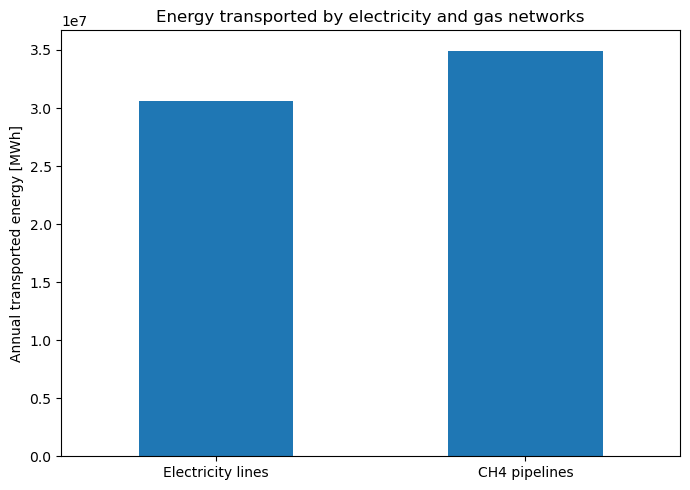


--- Gas-to-power capacities ---
                         bus0     bus1      p_nom_opt  efficiency
name                                                             
CH4_to_power_DK1  CH4_bus_DK1  bus_DK1      -0.000000        0.39
CH4_to_power_DK2  CH4_bus_DK2  bus_DK2    4390.713213        0.39
CH4_to_power_NO2  CH4_bus_NO2  bus_NO2      -0.000000        0.39
CH4_to_power_DE    CH4_bus_DE   bus_DE  185367.008556        0.39

--- Pipeline capacities and use ---
                             bus0         bus1   p_nom  efficiency
name                                                              
CH4_pipeline_DK1_NO2  CH4_bus_DK1  CH4_bus_NO2  3000.0        0.99
CH4_pipeline_DK1_DE   CH4_bus_DK1   CH4_bus_DE  5000.0        0.99
CH4_pipeline_DK1_DK2  CH4_bus_DK1  CH4_bus_DK2  1500.0        0.99
CH4_pipeline_DK2_DE   CH4_bus_DK2   CH4_bus_DE  3000.0        0.99

--- Max pipeline loading [%] ---
name
CH4_pipeline_DK1_NO2    100.0
CH4_pipeline_DK1_DE      90.0
CH4_pipeline_DK1_DK2    100.0
CH4

In [7]:
# =============================================================
# RESULTS: Compare electricity and gas transport
# =============================================================

# Electricity transported through HVAC lines
electricity_transport_MWh = n_g.lines_t.p0.abs().sum().sum()

# Gas transported through CH4 pipelines
pipeline_names = [
    link for link in n_g.links.index
    if "CH4_pipeline" in link
]

gas_transport_MWh = n_g.links_t.p0[pipeline_names].abs().sum().sum()

print("\n--- Transported energy ---")
print(f"Electricity transported by HVAC lines: {electricity_transport_MWh:,.0f} MWh")
print(f"CH4 transported by gas pipelines: {gas_transport_MWh:,.0f} MWh")

if gas_transport_MWh > electricity_transport_MWh:
    print("The gas pipeline network transports more energy.")
else:
    print("The electricity transmission network transports more energy.")


# -------------------------------------------------------------
# Plot comparison
# -------------------------------------------------------------
transport_comparison = pd.Series({
    "Electricity lines": electricity_transport_MWh,
    "CH4 pipelines": gas_transport_MWh
})

ax = transport_comparison.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.ylabel("Annual transported energy [MWh]")
plt.title("Energy transported by electricity and gas networks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------
# Additional useful outputs
# -------------------------------------------------------------
print("\n--- Gas-to-power capacities ---")
print(n_g.links[n_g.links.carrier == "gas_to_power"][["bus0", "bus1", "p_nom_opt", "efficiency"]])

print("\n--- Pipeline capacities and use ---")
print(n_g.links.loc[pipeline_names, ["bus0", "bus1", "p_nom", "efficiency"]])

pipeline_loading = (
    n_g.links_t.p0[pipeline_names].abs().max()
    / n_g.links.loc[pipeline_names, "p_nom"]
    * 100
)

print("\n--- Max pipeline loading [%] ---")
print(pipeline_loading)

## Visualising 

/var/folders/ry/7cxb3jh14q1ggq8t49x0fy4h0000gn/T/ipykernel_35126/1674503727.py:90: UserWarning:



The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.


/var/folders/ry/7cxb3jh14q1ggq8t49x0fy4h0000gn/T/ipykernel_35126/1674503727.py:108: UserWarning:



The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.




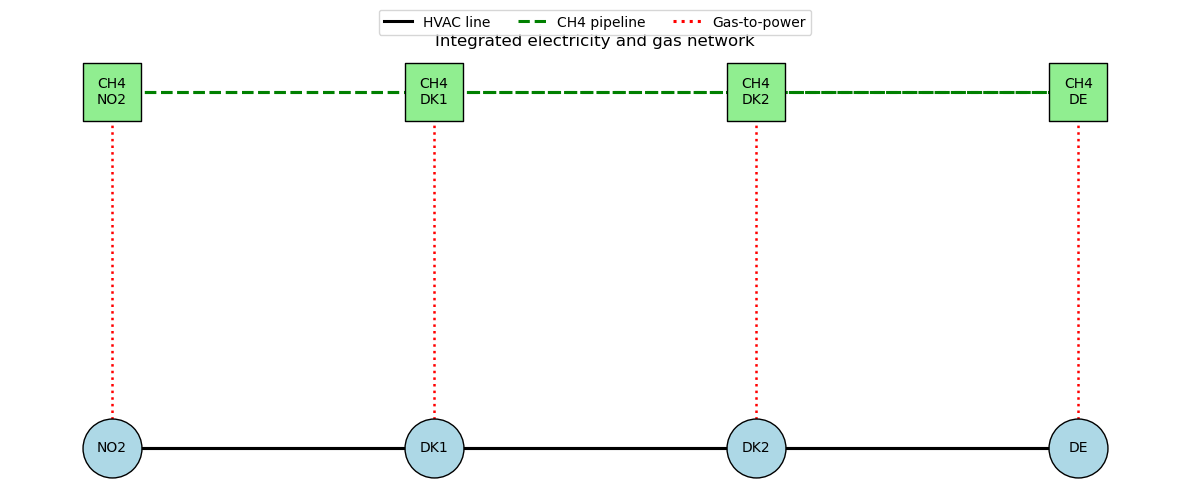

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# -----------------------------
# Nodes
# -----------------------------
el_nodes = ["NO2", "DK1", "DK2", "DE"]
gas_nodes = [f"CH4_{n}" for n in el_nodes]

G.add_nodes_from(el_nodes + gas_nodes)

# -----------------------------
# Edges
# -----------------------------
electricity_links = [
    ("NO2", "DK1"),
    ("DK1", "DK2"),
    ("DK2", "DE"),
    ("NO2", "DE"),      # replaces diagonal DK1-DE visually
]

gas_links = [
    ("CH4_NO2", "CH4_DK1"),
    ("CH4_DK1", "CH4_DK2"),
    ("CH4_DK2", "CH4_DE"),
    ("CH4_NO2", "CH4_DE"),   # long lower/upper connection
]

conversion_links = [
    ("CH4_NO2", "NO2"),
    ("CH4_DK1", "DK1"),
    ("CH4_DK2", "DK2"),
    ("CH4_DE", "DE"),
]

G.add_edges_from(electricity_links + gas_links + conversion_links)

# -----------------------------
# Clean parallel positions
# -----------------------------
pos = {
    # Electricity layer
    "NO2": (0, 0),
    "DK1": (2, 0),
    "DK2": (4, 0),
    "DE":  (6, 0),

    # Gas layer
    "CH4_NO2": (0, 2),
    "CH4_DK1": (2, 2),
    "CH4_DK2": (4, 2),
    "CH4_DE":  (6, 2),
}

plt.figure(figsize=(12, 5))

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=el_nodes,
    node_color="lightblue",
    edgecolors="black",
    node_size=1800
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=gas_nodes,
    node_color="lightgreen",
    edgecolors="black",
    node_shape="s",
    node_size=1700
)

# Labels
labels = {node: node.replace("CH4_", "CH4\n") for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10)

# Electricity lines
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("NO2", "DK1"), ("DK1", "DK2"), ("DK2", "DE")],
    width=2.2,
    edge_color="black"
)

# Extra electricity connection drawn as a clean bottom line
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("NO2", "DE")],
    width=2.2,
    edge_color="black",
    connectionstyle="arc3,rad=0.22"
)

# Gas pipelines
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("CH4_NO2", "CH4_DK1"), ("CH4_DK1", "CH4_DK2"), ("CH4_DK2", "CH4_DE")],
    width=2.2,
    edge_color="green",
    style="dashed"
)

# Extra gas connection drawn as a clean top line
nx.draw_networkx_edges(
    G, pos,
    edgelist=[("CH4_NO2", "CH4_DE")],
    width=2.2,
    edge_color="green",
    style="dashed",
    connectionstyle="arc3,rad=-0.22"
)

# Gas-to-power links
nx.draw_networkx_edges(
    G, pos,
    edgelist=conversion_links,
    width=1.8,
    edge_color="red",
    style="dotted"
)

# Legend
plt.plot([], [], color="black", linewidth=2.2, label="HVAC line")
plt.plot([], [], color="green", linestyle="--", linewidth=2.2, label="CH4 pipeline")
plt.plot([], [], color="red", linestyle=":", linewidth=2.2, label="Gas-to-power")

plt.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.12))
plt.title("Integrated electricity and gas network")
plt.axis("off")
plt.tight_layout()
plt.savefig("Figures/task_g_network_clean.png", dpi=300, bbox_inches="tight")
plt.show()

## Task I

Variables in GRIB file: ['t2m']

HDH summary:
count    8760.000000
mean        6.311329
std         5.537908
min         0.000000
25%         0.182481
50%         5.694651
75%        10.953942
max        20.832012
Name: t2m, dtype: float64

Heat profile check:
Sum: 1.0
Min: 0.0
Max: 0.00037679600063711405

Final heat demand summary:
count    8760.000000
mean        0.000114
std         0.000100
min         0.000000
25%         0.000003
50%         0.000103
75%         0.000198
max         0.000377
Name: t2m, dtype: float64
Annual heat demand: 1.0
Annual heat demand [MWh]: 5.910817e+06


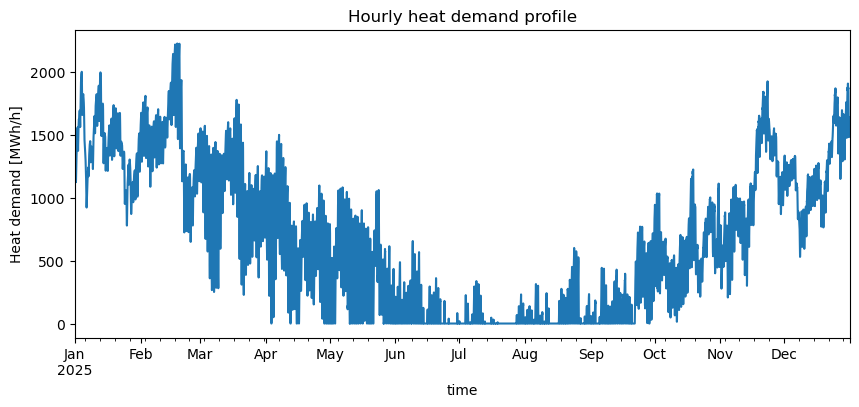

In [11]:
# =====================================================
# USER INPUTS
# =====================================================

GRIB_FILE = "Data/weather_data_2025"  # path to ERA5 GRIB file
T_BASE = 15.0                             # base temperature [°C]
ANNUAL_HEAT_DEMAND = 1.0                 # arbitrary (normalised later)

# =====================================================
# STEP 1 — Read GRIB file
# =====================================================

ds = xr.open_dataset(GRIB_FILE, engine="cfgrib")

print("Variables in GRIB file:", list(ds.data_vars))

# =====================================================
# STEP 2 — Extract temperature and convert to Celsius
# =====================================================

# ERA5 temperature is in Kelvin
temperature_C = ds["t2m"] - 273.15

# =====================================================
# STEP 3 — Spatial average (country-level)
# =====================================================

temperature_country = temperature_C.mean(dim=["latitude", "longitude"])

# Convert to pandas Series
temperature_country = temperature_country.to_pandas()

# Make index timezone-naive (important later)
if temperature_country.index.tz is not None:
    temperature_country.index = temperature_country.index.tz_convert("UTC").tz_localize(None)

# =====================================================
# STEP 4 — Compute Heating Degree Hours (HDH)
# =====================================================

hdh = (T_BASE - temperature_country).clip(lower=0.0)

print("\nHDH summary:")
print(hdh.describe())

assert hdh.sum() > 0, "HDH is zero — temperature data is wrong"

# =====================================================
# STEP 5 — Normalise to a heat profile
# =====================================================

heat_profile = hdh / hdh.sum()

print("\nHeat profile check:")
print("Sum:", heat_profile.sum())
print("Min:", heat_profile.min())
print("Max:", heat_profile.max())

assert np.isclose(heat_profile.sum(), 1.0), "Heat profile does not sum to 1"

# =====================================================
# STEP 6 — Scale to annual heat demand
# =====================================================

heat_demand = heat_profile * ANNUAL_HEAT_DEMAND

print("\nFinal heat demand summary:")
print(heat_demand.describe())
print("Annual heat demand:", heat_demand.sum())



annual_electricity = electricity_load.sum()   # MWh
alpha = 0.25                                  # Denmark example

annual_heat_demand = alpha * annual_electricity

heat_demand = heat_profile * annual_heat_demand

print("Annual heat demand [MWh]:", heat_demand.sum())


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
heat_demand.plot(ax=ax)
ax.set_ylabel("Heat demand [MWh/h]")
ax.set_title("Hourly heat demand profile")
plt.show()


In [ ]:
# Additional heat demand relative to electricity demand
# (represents future electrification of heating)
alpha = {
    "DK1": 0.25,   # Denmark: already many heat pumps
    "DK2": 0.25,
    "NO2": 0.20,   # Norway: lots of electric heating already
    "DE":  0.60,   # Germany: mostly fossil heating today
}

# Heat pump assumptions
COP = 3.0                       # constant COP
hp_annualised_cost = 80_000     # €/MW_th (example, cite in report)

for zone in ["DK1", "DK2", "NO2", "DE"]:

    # -------------------------------------------------
    # 1) Scale heat profile to annual heat demand
    # -------------------------------------------------

    electricity_load = pivot_load(zone)
    annual_electricity = electricity_load.sum()          # MWh

    annual_heat_demand = alpha[zone] * annual_electricity

    heat_demand = heat_profile * annual_heat_demand

    # Align to network snapshots (safe at this stage)
    heat_demand = heat_demand.reindex(multi_n.snapshots).fillna(0.0)

    # -------------------------------------------------
    # 2) Add heat bus
    # -------------------------------------------------

    multi_n.add(
        "Bus",
        f"heat_{zone}",
        carrier="heat"
    )

    # -------------------------------------------------
    # 3) Add heat demand
    # -------------------------------------------------

    multi_n.add(
        "Load",
        f"heat_load_{zone}",
        bus=f"heat_{zone}",
        p_set=heat_demand
    )

    # -------------------------------------------------
    # 4) Add heat pump (electricity -> heat)
    # -------------------------------------------------

    multi_n.add(
        "Link",
        f"heat_pump_{zone}",
        bus0=f"bus_{zone}",      # electricity
        bus1=f"heat_{zone}",     # heat
        efficiency=COP,
        p_nom_extendable=True,
        capital_cost=hp_annualised_cost,
        marginal_cost=0.0,
        carrier="heat_pump"
    )


print(multi_n.buses[ multi_n.buses.carrier == "heat" ])
print(multi_n.loads[ multi_n.loads.index.str.contains("heat") ])
print(multi_n.links[ multi_n.links.carrier == "heat_pump" ])


          v_nom type    x    y carrier unit location  v_mag_pu_set  \
name                                                                 
heat_DK1    1.0       0.0  0.0    heat                         1.0   
heat_DK2    1.0       0.0  0.0    heat                         1.0   
heat_NO2    1.0       0.0  0.0    heat                         1.0   
heat_DE     1.0       0.0  0.0    heat                         1.0   

          v_mag_pu_min  v_mag_pu_max control generator sub_network slack  
name                                                                      
heat_DK1           0.0           inf      PQ                         NaN  
heat_DK2           0.0           inf      PQ                         NaN  
heat_NO2           0.0           inf      PQ                         NaN  
heat_DE            0.0           inf      PQ                         NaN  
                    bus carrier type  p_set  q_set  sign  active
name                                                            

In [13]:
multi_n.optimize()

Index(['heat_DK1', 'heat_DK2', 'heat_NO2', 'heat_DE'], dtype='str', name='name')
Index(['heat_pump_DK1', 'heat_pump_DK2', 'heat_pump_NO2', 'heat_pump_DE'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 427.61it/s]
INFO:linopy.io: Writing time: 0.35s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-7yl45qa0 has 708690 rows; 297488 cols; 1328466 nonzeros
Coefficient ranges:
  Matrix  [1e-06, 1e+04]
  Cost    [1e+00, 3e+05]
  Bound   [5e+10, 5e+10]
  RHS     [6e-02, 3e+05]
Presolving model
313561 rows, 243589 cols, 844444 nonzeros  0s
Dependent equations search running on 69961 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
269785 rows, 234805 cols, 783230 nonzeros  0s
Presolve reductions: rows 269785(-438905); columns 234805(-62683); nonzeros 783230(-545236) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     5.0784917532e+09 Pr: 35005(9.05822e+08) 0.7s
      31309     1.0315094474e+11 Pr: 34603(1.064e+09) 6.1s
      42040     1.2588611479e+11 Pr: 34784(1.18556e+09); Du: 0(1.99656e-21) 11.4s
      74810     1.3778497611e+11 Pr: 28876(1.

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 297488 primals, 708690 duals
Objective: 1.42e+11
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-7yl45qa0
Model status        : Optimal
Simplex   iterations: 150175
Objective value     :  1.4158381224e+11
P-D objective error :  6.0029076582e-14
HiGHS run time      :         24.28


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

                  bus0      bus1     p_nom_opt
name                                          
heat_pump_DK1  bus_DK1  heat_DK1    742.390706
heat_pump_DK2  bus_DK2  heat_DK2    464.085449
heat_pump_NO2  bus_NO2  heat_NO2   3724.716146
heat_pump_DE    bus_DE   heat_DE  58505.875000


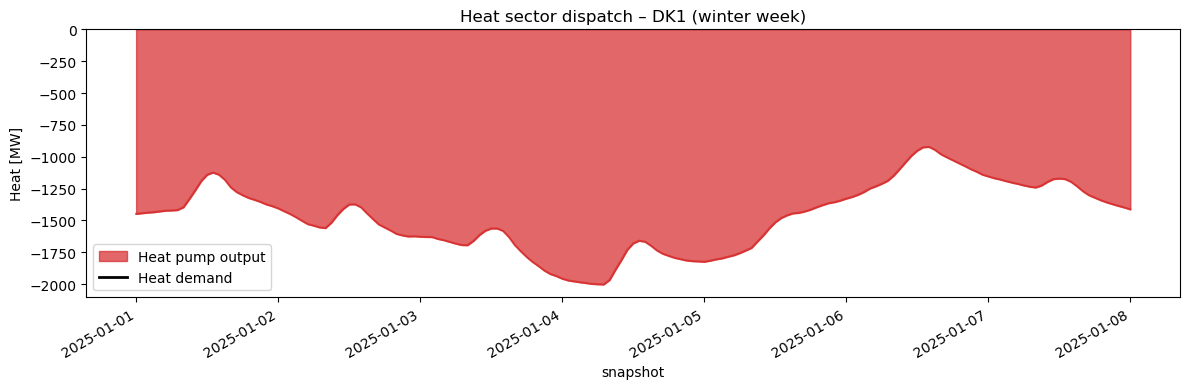

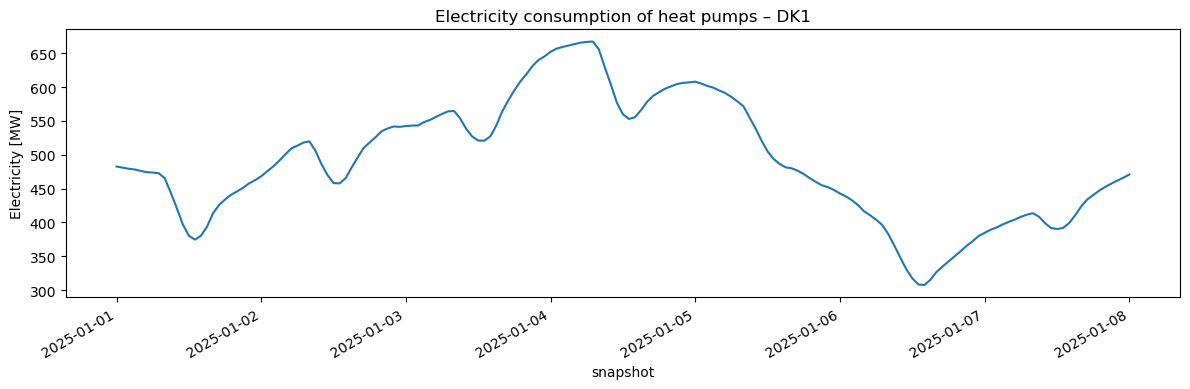

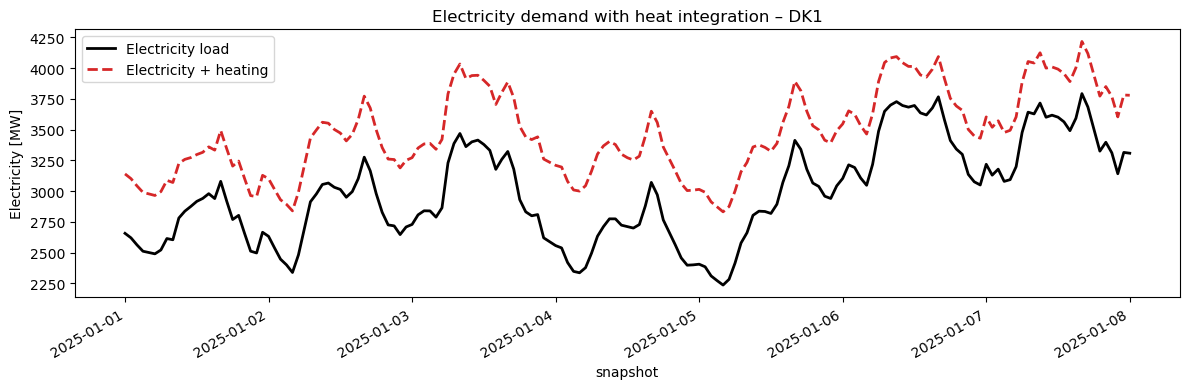

In [14]:
import matplotlib.pyplot as plt

def plot_heat_dispatch(n, zone, snapshots):
    heat_load = n.loads_t.p_set[f"heat_load_{zone}"].loc[snapshots]
    heat_pump = n.links_t.p1.loc[snapshots, f"heat_pump_{zone}"]

    fig, ax = plt.subplots(figsize=(12, 4))

    heat_pump.plot.area(ax=ax, color="tab:red", alpha=0.7, label="Heat pump output")
    heat_load.plot(ax=ax, color="black", linewidth=2, label="Heat demand")

    ax.set_ylabel("Heat [MW]")
    ax.set_title(f"Heat sector dispatch – {zone} (winter week)")
    ax.legend()
    plt.tight_layout()
    plt.show()



def plot_heat_pump_electricity_use(n, zone, snapshots):
    hp_electricity = n.links_t.p0.loc[snapshots, f"heat_pump_{zone}"]

    fig, ax = plt.subplots(figsize=(12, 4))

    hp_electricity.plot(ax=ax, color="tab:blue")

    ax.set_ylabel("Electricity [MW]")
    ax.set_title(f"Electricity consumption of heat pumps – {zone}")
    plt.tight_layout()
    plt.show()


def plot_electricity_load_with_heating(n, zone, snapshots):
    base_load = n.loads_t.p_set[f"load_{zone}"].loc[snapshots]
    hp_load = n.links_t.p0.loc[snapshots, f"heat_pump_{zone}"]

    fig, ax = plt.subplots(figsize=(12, 4))

    base_load.plot(ax=ax, color="black", linewidth=2, label="Electricity load")
    (base_load + hp_load).plot(
        ax=ax, color="tab:red", linewidth=2, linestyle="--",
        label="Electricity + heating"
    )

    ax.set_ylabel("Electricity [MW]")
    ax.set_title(f"Electricity demand with heat integration – {zone}")
    ax.legend()
    plt.tight_layout()
    plt.show()


hp = multi_n.links.loc[multi_n.links.carrier == "heat_pump"]

print(hp[hp.p_nom_opt > 1e-3][["bus0", "bus1", "p_nom_opt"]])

winter_week = multi_n.snapshots[multi_n.snapshots.month == 1][:168]
plot_heat_dispatch(multi_n, "DK1", winter_week)

plot_heat_pump_electricity_use(multi_n, "DK1", winter_week)

plot_electricity_load_with_heating(multi_n, "DK1", winter_week)
